In [5]:
!pip install -q xgboost

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [7]:
df = pd.read_csv("airline_passenger_satisfaction.csv")

In [8]:
print(df.head())
print(df.info())
print(df.describe())

   ID  Gender  Age Customer Type Type of Travel     Class  Flight Distance  \
0   1    Male   48    First-time       Business  Business              821   
1   2  Female   35     Returning       Business  Business              821   
2   3    Male   41     Returning       Business  Business              853   
3   4    Male   50     Returning       Business  Business             1905   
4   5  Female   49     Returning       Business  Business             3470   

   Departure Delay  Arrival Delay  Departure and Arrival Time Convenience  \
0                2            5.0                                       3   
1               26           39.0                                       2   
2                0            0.0                                       4   
3                0            0.0                                       2   
4                0            1.0                                       3   

   ...  On-board Service  Seat Comfort  Leg Room Service  Cleanlines

In [9]:
print("Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Shape: (129880, 24)

Column Names:
['ID', 'Gender', 'Age', 'Customer Type', 'Type of Travel', 'Class', 'Flight Distance', 'Departure Delay', 'Arrival Delay', 'Departure and Arrival Time Convenience', 'Ease of Online Booking', 'Check-in Service', 'Online Boarding', 'Gate Location', 'On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness', 'Food and Drink', 'In-flight Service', 'In-flight Wifi Service', 'In-flight Entertainment', 'Baggage Handling', 'Satisfaction']

Data Types:
ID                                          int64
Gender                                     object
Age                                         int64
Customer Type                              object
Type of Travel                             object
Class                                      object
Flight Distance                             int64
Departure Delay                             int64
Arrival Delay                             float64
Departure and Arrival Time Convenience      int64
Ease o

In [10]:
print("Target Distribution:")
print(df["Satisfaction"].value_counts())

print("\nTarget Percentage:")
print(df["Satisfaction"].value_counts(normalize=True).round(3) * 100)

Target Distribution:
Satisfaction
Neutral or Dissatisfied    73452
Satisfied                  56428
Name: count, dtype: int64

Target Percentage:
Satisfaction
Neutral or Dissatisfied    56.6
Satisfied                  43.4
Name: proportion, dtype: float64


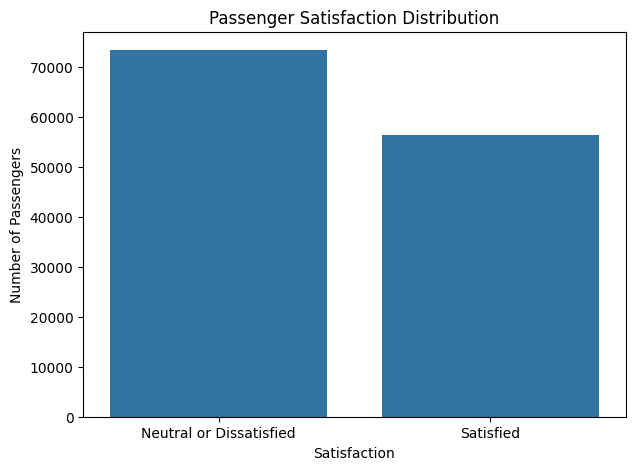

In [11]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Satisfaction")

plt.title("Passenger Satisfaction Distribution")
plt.xlabel("Satisfaction")
plt.ylabel("Number of Passengers")

plt.show()

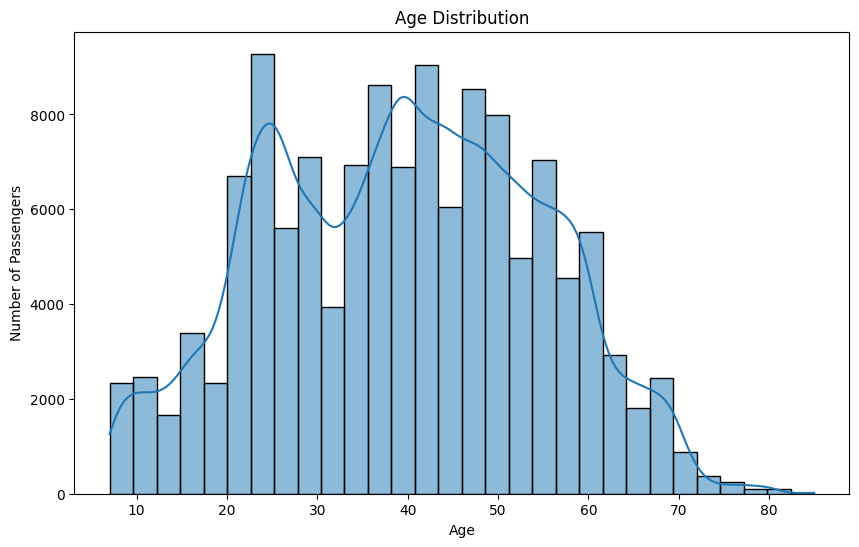

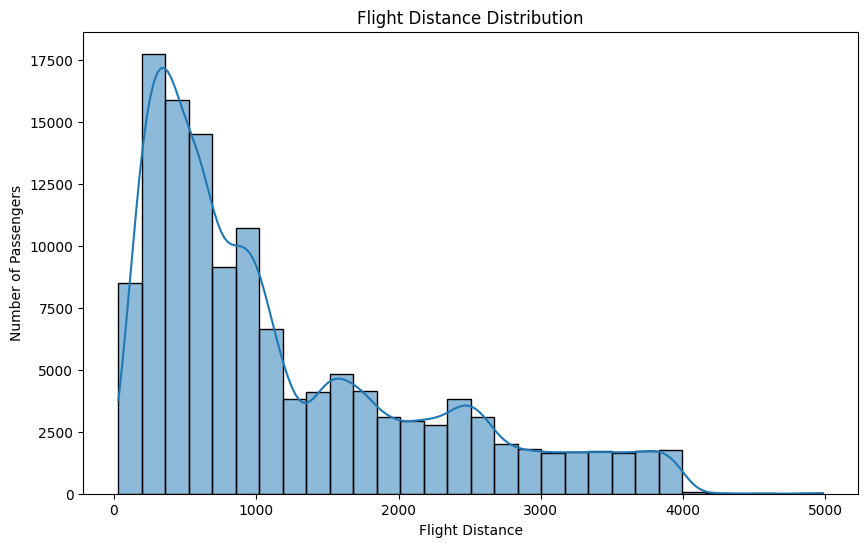

In [12]:
plt.figure(figsize=(10, 6))

sns.histplot(data=df, x="Age", bins=30, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

plt.figure(figsize=(10, 6))

sns.histplot(data=df, x="Flight Distance", bins=30, kde=True)

plt.title("Flight Distance Distribution")
plt.xlabel("Flight Distance")
plt.ylabel("Number of Passengers")

plt.show()

In [13]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
['ID', 'Age', 'Flight Distance', 'Departure Delay', 'Arrival Delay', 'Departure and Arrival Time Convenience', 'Ease of Online Booking', 'Check-in Service', 'Online Boarding', 'Gate Location', 'On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness', 'Food and Drink', 'In-flight Service', 'In-flight Wifi Service', 'In-flight Entertainment', 'Baggage Handling']

Categorical Columns:
['Gender', 'Customer Type', 'Type of Travel', 'Class', 'Satisfaction']


In [14]:
X = df.drop(["Satisfaction", "ID"], axis=1)

y = df["Satisfaction"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (129880, 22)
y shape: (129880,)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (103904, 22)
X_test: (25976, 22)
y_train: (103904,)
y_test: (25976,)


In [16]:
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Number of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

print("\nNumerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Number of numerical features: 18
Number of categorical features: 4

Numerical features:
['Age', 'Flight Distance', 'Departure Delay', 'Arrival Delay', 'Departure and Arrival Time Convenience', 'Ease of Online Booking', 'Check-in Service', 'Online Boarding', 'Gate Location', 'On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness', 'Food and Drink', 'In-flight Service', 'In-flight Wifi Service', 'In-flight Entertainment', 'Baggage Handling']

Categorical features:
['Gender', 'Customer Type', 'Type of Travel', 'Class']


In [17]:
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [18]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [19]:
y_pred_lr = logistic_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr, pos_label="Satisfied")
lr_recall = recall_score(y_test, y_pred_lr, pos_label="Satisfied")
lr_f1 = f1_score(y_test, y_pred_lr, pos_label="Satisfied")

print("Logistic Regression Results")
print("-" * 40)

print("Accuracy:", lr_accuracy)
print("Precision:", lr_precision)
print("Recall:", lr_recall)
print("F1 Score:", lr_f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results
----------------------------------------
Accuracy: 0.8771558361564521
Precision: 0.8715688974570825
Recall: 0.8412192096402623
F1 Score: 0.8561251634428965

Classification Report:
                         precision    recall  f1-score   support

Neutral or Dissatisfied       0.88      0.90      0.89     14690
              Satisfied       0.87      0.84      0.86     11286

               accuracy                           0.88     25976
              macro avg       0.88      0.87      0.87     25976
           weighted avg       0.88      0.88      0.88     25976



In [20]:
random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

random_forest_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [21]:
y_pred_rf = random_forest_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, pos_label="Satisfied")
rf_recall = recall_score(y_test, y_pred_rf, pos_label="Satisfied")
rf_f1 = f1_score(y_test, y_pred_rf, pos_label="Satisfied")

print("Random Forest Results")
print("-" * 40)

print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1 Score:", rf_f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
----------------------------------------
Accuracy: 0.9640822297505389
Precision: 0.9742556115437472
Recall: 0.9422293106503633
F1 Score: 0.9579748659970272

Classification Report:
                         precision    recall  f1-score   support

Neutral or Dissatisfied       0.96      0.98      0.97     14690
              Satisfied       0.97      0.94      0.96     11286

               accuracy                           0.96     25976
              macro avg       0.97      0.96      0.96     25976
           weighted avg       0.96      0.96      0.96     25976



In [22]:
y_train_xgb = y_train.map({
    "Neutral or Dissatisfied": 0,
    "Satisfied": 1
})

y_test_xgb = y_test.map({
    "Neutral or Dissatisfied": 0,
    "Satisfied": 1
})

print(y_train_xgb.value_counts())

Satisfaction
0    58762
1    45142
Name: count, dtype: int64


In [23]:
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    ))
])

xgb_model.fit(X_train, y_train_xgb)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [24]:
y_pred_xgb = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test_xgb, y_pred_xgb)
xgb_precision = precision_score(y_test_xgb, y_pred_xgb)
xgb_recall = recall_score(y_test_xgb, y_pred_xgb)
xgb_f1 = f1_score(y_test_xgb, y_pred_xgb)

print("XGBoost Results")
print("-" * 40)

print("Accuracy:", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall:", xgb_recall)
print("F1 Score:", xgb_f1)

print("\nClassification Report:")
print(
    classification_report(
        y_test_xgb,
        y_pred_xgb,
        target_names=["Neutral or Dissatisfied", "Satisfied"]
    )
)

XGBoost Results
----------------------------------------
Accuracy: 0.9617339082229751
Precision: 0.9715044896463259
Recall: 0.9394825447457026
F1 Score: 0.9552252252252252

Classification Report:
                         precision    recall  f1-score   support

Neutral or Dissatisfied       0.95      0.98      0.97     14690
              Satisfied       0.97      0.94      0.96     11286

               accuracy                           0.96     25976
              macro avg       0.96      0.96      0.96     25976
           weighted avg       0.96      0.96      0.96     25976



In [25]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        lr_precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        lr_recall,
        rf_recall,
        xgb_recall
    ],
    "F1 Score": [
        lr_f1,
        rf_f1,
        xgb_f1
    ]
})

results = results.sort_values(
    by="F1 Score",
    ascending=False
)

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
1        Random Forest  0.964082   0.974256  0.942229  0.957975
2              XGBoost  0.961734   0.971504  0.939483  0.955225
0  Logistic Regression  0.877156   0.871569  0.841219  0.856125


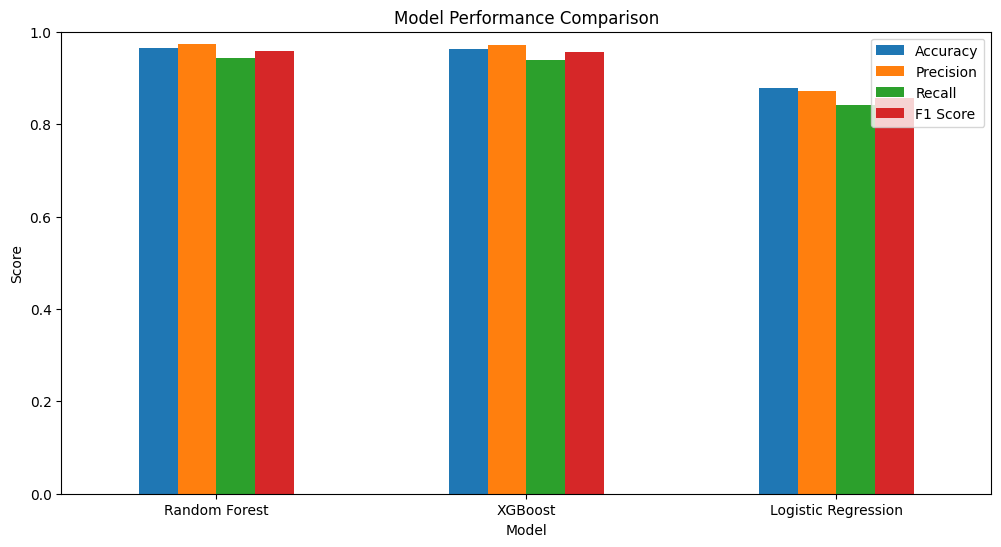

In [26]:
results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.show()

In [27]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

lr_cv = cross_validate(
    logistic_model,
    X,
    y.map({
        "Neutral or Dissatisfied": 0,
        "Satisfied": 1
    }),
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Logistic Regression CV F1:")
print(lr_cv["test_f1"].mean())

rf_cv = cross_validate(
    random_forest_model,
    X,
    y.map({
        "Neutral or Dissatisfied": 0,
        "Satisfied": 1
    }),
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Random Forest CV F1:")
print(rf_cv["test_f1"].mean())

Logistic Regression CV F1:
0.8524913415791378
Random Forest CV F1:
0.957450880107079


In [42]:
from sklearn.metrics import make_scorer

f1_satisfied = make_scorer(
    f1_score,
    pos_label="Satisfied"
)

rf_cv_fixed = cross_validate(
    best_rf_model,
    X,
    y,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "precision": make_scorer(
            precision_score,
            pos_label="Satisfied"
        ),
        "recall": make_scorer(
            recall_score,
            pos_label="Satisfied"
        ),
        "f1": f1_satisfied
    },
    n_jobs=-1
)

print("Cross Validation Results")
print("-" * 40)

print("Accuracy:", rf_cv_fixed["test_accuracy"].mean())
print("Precision:", rf_cv_fixed["test_precision"].mean())
print("Recall:", rf_cv_fixed["test_recall"].mean())
print("F1 Score:", rf_cv_fixed["test_f1"].mean())

Cross Validation Results
----------------------------------------
Accuracy: 0.9607714813674161
Precision: 0.9657411429799149
Recall: 0.9431664608368664
F1 Score: 0.9543181458314487


In [29]:
best_rf_model = rf_search.best_estimator_

y_pred_best_rf = best_rf_model.predict(X_test)

best_rf_accuracy = accuracy_score(y_test, y_pred_best_rf)
best_rf_precision = precision_score(
    y_test,
    y_pred_best_rf,
    pos_label="Satisfied"
)
best_rf_recall = recall_score(
    y_test,
    y_pred_best_rf,
    pos_label="Satisfied"
)
best_rf_f1 = f1_score(
    y_test,
    y_pred_best_rf,
    pos_label="Satisfied"
)

print("Tuned Random Forest Results")
print("-" * 40)

print("Accuracy:", best_rf_accuracy)
print("Precision:", best_rf_precision)
print("Recall:", best_rf_recall)
print("F1 Score:", best_rf_f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_rf))

Tuned Random Forest Results
----------------------------------------
Accuracy: 0.9606174930705267
Precision: 0.964515253009867
Recall: 0.9440900230373914
F1 Score: 0.9541933461693458

Classification Report:
                         precision    recall  f1-score   support

Neutral or Dissatisfied       0.96      0.97      0.97     14690
              Satisfied       0.96      0.94      0.95     11286

               accuracy                           0.96     25976
              macro avg       0.96      0.96      0.96     25976
           weighted avg       0.96      0.96      0.96     25976



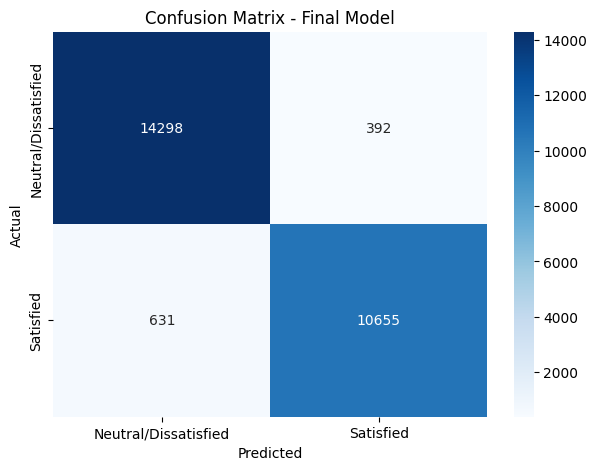

In [30]:
cm = confusion_matrix(y_test, y_pred_best_rf)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Neutral/Dissatisfied", "Satisfied"],
    yticklabels=["Neutral/Dissatisfied", "Satisfied"]
)

plt.title("Confusion Matrix - Final Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [31]:
train_pred = best_rf_model.predict(X_train)
test_pred = best_rf_model.predict(X_test)

train_f1 = f1_score(
    y_train,
    train_pred,
    pos_label="Satisfied"
)

test_f1 = f1_score(
    y_test,
    test_pred,
    pos_label="Satisfied"
)

print("Training F1:", train_f1)
print("Testing F1:", test_f1)
print("Difference:", train_f1 - test_f1)

Training F1: 0.9708605268165993
Testing F1: 0.9541933461693458
Difference: 0.016667180647253477


In [32]:
feature_names = best_rf_model.named_steps[
    "preprocessor"
].get_feature_names_out()

feature_importances = best_rf_model.named_steps[
    "model"
].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(20))

                                        Feature  Importance
7                          num__Online Boarding    0.157114
15                  num__In-flight Wifi Service    0.151764
24                          cat__Class_Business    0.088109
23                 cat__Type of Travel_Personal    0.083299
16                 num__In-flight Entertainment    0.067999
22                 cat__Type of Travel_Business    0.054082
10                            num__Seat Comfort    0.051474
5                   num__Ease of Online Booking    0.035707
20                cat__Customer Type_First-time    0.032093
21                 cat__Customer Type_Returning    0.030749
25                           cat__Class_Economy    0.028390
11                        num__Leg Room Service    0.025829
9                         num__On-board Service    0.025068
12                             num__Cleanliness    0.024517
17                        num__Baggage Handling    0.021669
6                         num__Check-in 

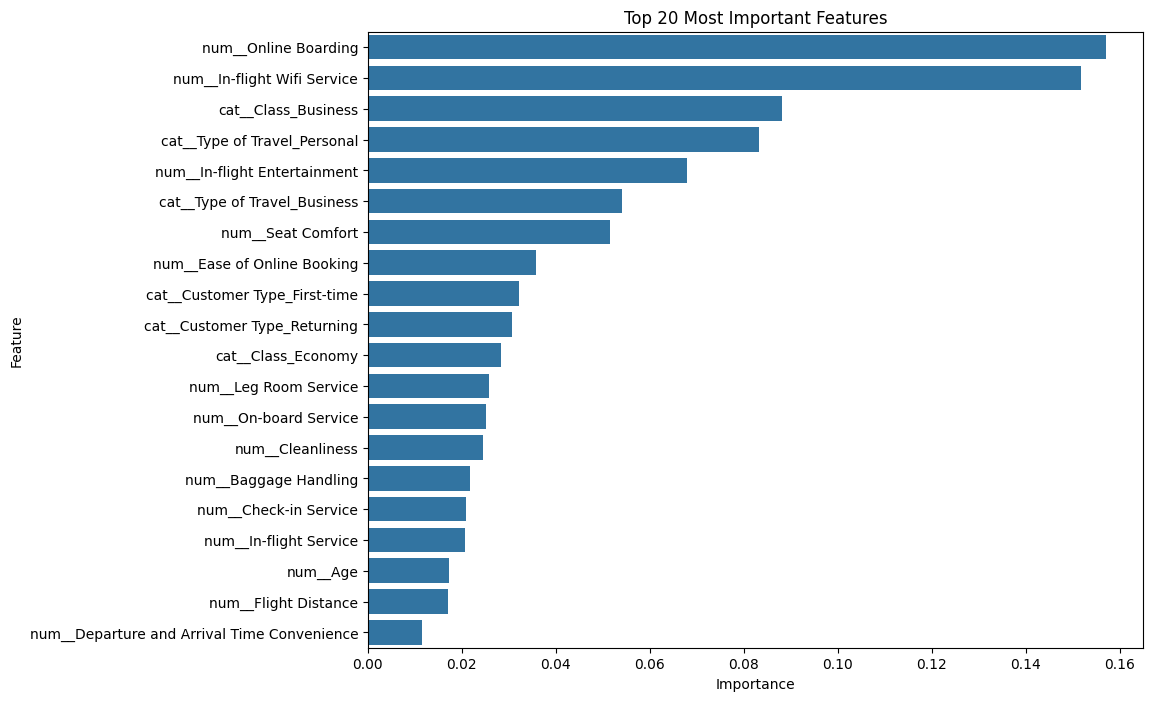

In [33]:
top_features = importance_df.head(20)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Most Important Features")

plt.show()

In [34]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        xgb_accuracy,
        best_rf_accuracy
    ],
    "Precision": [
        lr_precision,
        rf_precision,
        xgb_precision,
        best_rf_precision
    ],
    "Recall": [
        lr_recall,
        rf_recall,
        xgb_recall,
        best_rf_recall
    ],
    "F1 Score": [
        lr_f1,
        rf_f1,
        xgb_f1,
        best_rf_f1
    ]
})

final_results = final_results.sort_values(
    by="F1 Score",
    ascending=False
)

print(final_results)

                 Model  Accuracy  Precision    Recall  F1 Score
1        Random Forest  0.964082   0.974256  0.942229  0.957975
2              XGBoost  0.961734   0.971504  0.939483  0.955225
3  Tuned Random Forest  0.960617   0.964515  0.944090  0.954193
0  Logistic Regression  0.877156   0.871569  0.841219  0.856125


In [35]:
import joblib

joblib.dump(
    best_rf_model,
    "airline_satisfaction_final_model.pkl"
)

print("Final model saved successfully!")

Final model saved successfully!


In [38]:
new_passenger = pd.DataFrame({
    "Gender": ["Male"],
    "Customer Type": ["Loyal Customer"],
    "Age": [30],
    "Type of Travel": ["Business travel"],
    "Class": ["Business"],
    "Flight Distance": [1200],
    "In-flight Wifi Service": [4], # Corrected column name
    "Departure and Arrival Time Convenience": [4], # Corrected column name
    "Ease of Online Booking": [4], # Corrected column name
    "Gate Location": [4], # Corrected column name
    "Food and Drink": [4], # Corrected column name
    "Online Boarding": [5], # Corrected column name
    "Seat Comfort": [4], # Corrected column name
    "In-flight Entertainment": [4], # Corrected column name
    "On-board Service": [4], # Corrected column name
    "Leg Room Service": [4], # Corrected column name
    "Baggage Handling": [4], # Corrected column name
    "Check-in Service": [4], # Corrected column name
    "In-flight Service": [4], # Corrected column name
    "Cleanliness": [4],
    "Departure Delay": [5], # Corrected column name
    "Arrival Delay": [10] # Corrected column name
})

prediction = best_rf_model.predict(new_passenger)

print("Prediction:", prediction[0])

Prediction: Satisfied


In [41]:
print("DATA LEAKAGE CHECK")
print("=" * 40)

print("Target column in X:", "Satisfaction" in X.columns)
print("ID column in X:", "ID" in X.columns)

print("\nPreprocessing is inside the Pipeline:")
print("Imputation: Yes")
print("Encoding: Yes")
print("Scaling: Yes")

print("\nTrain/Test split performed before model training:")
print("Yes")

print("\nData Leakage Status: No obvious data leakage detected.")

DATA LEAKAGE CHECK
Target column in X: False
ID column in X: False

Preprocessing is inside the Pipeline:
Imputation: Yes
Encoding: Yes
Scaling: Yes

Train/Test split performed before model training:
Yes

Data Leakage Status: No obvious data leakage detected.


In [46]:
print("========================================")
print("AIRLINE PASSENGER SATISFACTION PROJECT")
print("========================================")

print("\nDataset Shape:", df.shape)

print("\nBest Model:")
print(final_results.iloc[0]["Model"])

print("\nBest Accuracy:")
print(round(final_results.iloc[0]["Accuracy"], 4))

print("\nBest Precision:")
print(round(final_results.iloc[0]["Precision"], 4))

print("\nBest Recall:")
print(round(final_results.iloc[0]["Recall"], 4))

print("\nBest F1 Score:")
print(round(final_results.iloc[0]["F1 Score"], 4))

print("\nProject completed successfully!")

AIRLINE PASSENGER SATISFACTION PROJECT

Dataset Shape: (129880, 24)

Best Model:
Random Forest

Best Accuracy:
0.9641

Best Precision:
0.9743

Best Recall:
0.9422

Best F1 Score:
0.958

Project completed successfully!
